In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

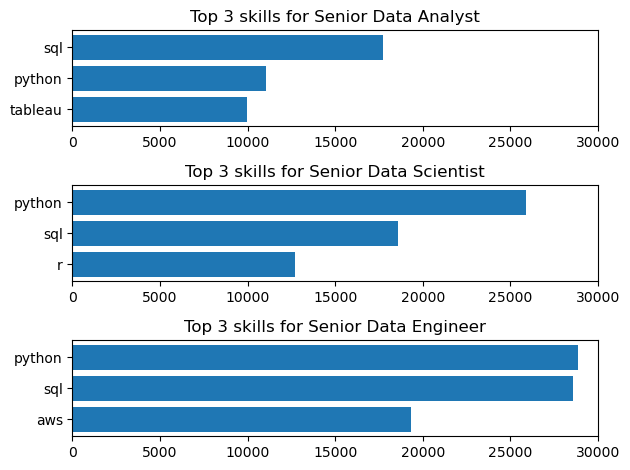

In [ ]:
fig, ax = plt.subplots(3, 1)

job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']

df_exploded = df.explode('job_skills').copy()

for i, job in enumerate(job_roles):

    plot_char = (
        df_exploded[df_exploded['job_title_short'] == job]
        .groupby('job_skills')
        .size()
        .sort_values(ascending=False)
        .head(3)
    )
    
    ax[i].barh(plot_char.index, plot_char.values,)
    ax[i].set_title(f'Top 3 skills for {job}')
    ax[i].set_xlim(0, 30000)
    ax[i].invert_yaxis()

fig.tight_layout()
plt.show()


